用来画图说明τ和曲线斜率并没有单调性

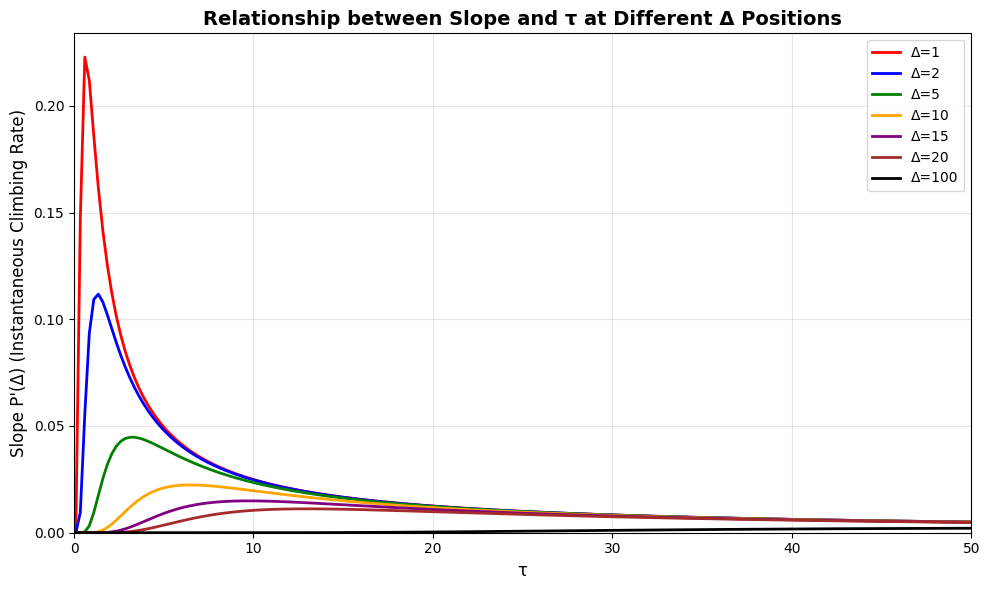

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # Suppress irrelevant warnings

# ===================== Core Parameter Settings =====================
x0 = 0          # Inflection point position (fixed)
A = 1           # Maximum value of the curve (fixed)
delta_list = [1, 2, 5, 10, 15, 20, 100]  # Specified Δ values
tau_range = np.linspace(0.1, 50, 200)  # τ value range (0.1 to 50, covering full trend)
# Extended color list to match delta_list length
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'black']  
labels = [f'Δ={d}' for d in delta_list]  # Legend labels

# ===================== Define Slope Calculation Function =====================
def logistic_derivative(delta, tau, x0=x0, A=A):
    """Calculate the slope (first derivative) of Logistic function at specified Δ and τ"""
    z = (delta - x0) / tau
    exp_term = np.exp(-z)
    derivative = (A / tau) * (exp_term / (1 + exp_term)**2)
    return derivative

# ===================== Calculation and Plotting =====================
plt.figure(figsize=(10, 6), dpi=100)

# Iterate over each Δ value, calculate slopes for different τ and plot
for delta, color, label in zip(delta_list, colors, labels):
    slope_values = logistic_derivative(delta, tau_range)
    plt.plot(tau_range, slope_values, color=color, label=label, linewidth=2)

# ===================== Plot Styling (Paper-level) =====================
plt.xlabel('τ', fontsize=12)
plt.ylabel('Slope P\'(Δ) (Instantaneous Climbing Rate)', fontsize=12)
plt.title('Relationship between Slope and τ at Different Δ Positions', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.xlim(0, 50)  # X-axis range
plt.ylim(bottom=0)  # Slope is non-negative, Y-axis starts from 0

plt.tight_layout()  # Auto-adjust layout
plt.show()

Font 'default' does not have a glyph for '\u5bfc' [U+5bfc], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u5e08' [U+5e08], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u6a21' [U+6a21], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u578b' [U+578b], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u57fa' [U+57fa], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u51c6' [U+51c6], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u4f60' [U+4f60], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u7684' [U+7684], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u6a21' [U+6a21], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u578b' [U+578b], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u5e73' [U+5e73], 

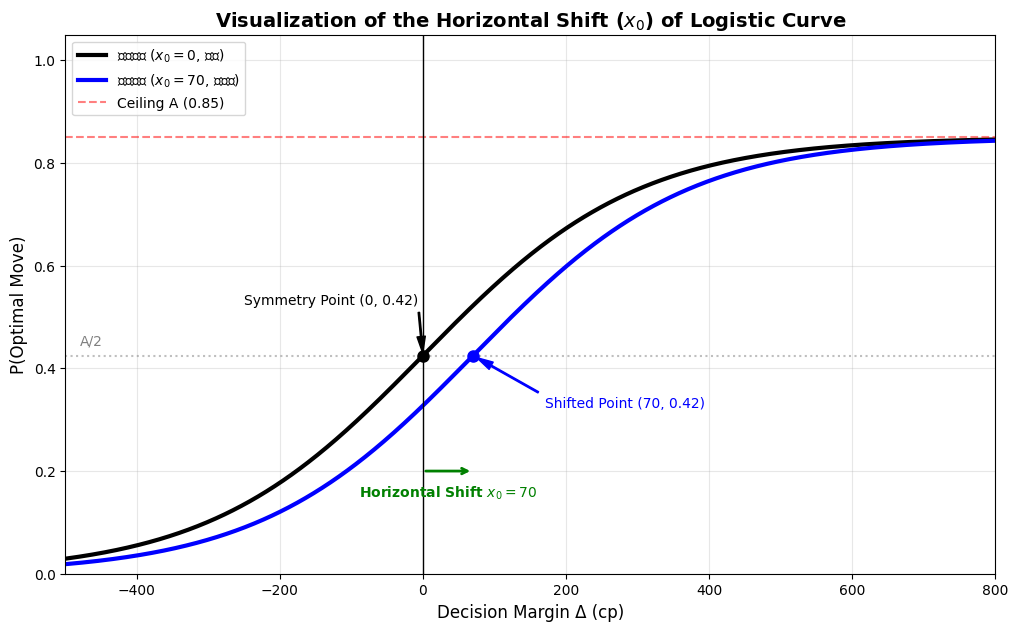

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 定义模型函数 ---
def model_2param(x, A, tau):
    """导师推荐的基础版 (x0 = 0)"""
    # 限制指数范围防止溢出
    exponent = np.clip(-x / tau, -500, 500)
    return A / (1 + np.exp(exponent))

def model_3param(x, A, tau, x0):
    """你的核心方案 (带 x0 平移)"""
    # 限制指数范围防止溢出
    exponent = np.clip(-(x - x0) / tau, -500, 500)
    return A / (1 + np.exp(exponent))

# --- 2. 设置演示参数 (选择一组典型的参数) ---
A_val = 0.85      # 天花板
tau_val = 150     # 坡度
x0_val = 70       # 你的平移门槛 (假设低分棋手)

# --- 3. 定义全景 X 轴 (包括负半轴) ---
# 我们从 -500cp 看通过 800cp
x_panorama = np.linspace(-500, 800, 1000)

# --- 4. 计算曲线数据 ---
y_base = model_2param(x_panorama, A_val, tau_val)
y_shifted = model_3param(x_panorama, A_val, tau_val, x0_val)

# --- 5. 绘图 ---
plt.figure(figsize=(12, 7))

# 画导师的模型 (x0 = 0) - 黑色实线
plt.plot(x_panorama, y_base, 'k-', lw=3, label=f'导师模型 ($x_0=0$, 基准)')

# 画你的模型 (x0 = 70) - 蓝色实线
plt.plot(x_panorama, y_shifted, 'b-', lw=3, label=f'你的模型 ($x_0={x0_val}$, 平移后)')

# --- 6. 添加关键修饰和标注 ---

# 画天花板 A
plt.axhline(y=A_val, color='r', linestyle='--', alpha=0.5, label=f'Ceiling A ({A_val})')

# 画中心点 A/2
plt.axhline(y=A_val/2, color='gray', linestyle=':', alpha=0.5)
plt.text(-480, A_val/2 + 0.02, 'A/2', color='gray', fontsize=10)

# 标注导师模型的中心点 (0, A/2)
plt.plot(0, A_val/2, 'ko', markersize=8)
plt.annotate(f'Symmetry Point (0, {A_val/2:.2f})', xy=(0, A_val/2), xytext=(-250, A_val/2 + 0.1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

# 标注你的模型的中心点 (x0, A/2)
plt.plot(x0_val, A_val/2, 'bo', markersize=8)
plt.annotate(f'Shifted Point ({x0_val}, {A_val/2:.2f})', xy=(x0_val, A_val/2), xytext=(x0_val + 100, A_val/2 - 0.1),
             color='blue', arrowprops=dict(facecolor='blue', edgecolor='blue', shrink=0.05, width=1, headwidth=6))

# 画平移箭头
plt.annotate('', xy=(x0_val, 0.2), xytext=(0, 0.2),
             arrowprops=dict(facecolor='green', edgecolor='green', arrowstyle='->', lw=2))
plt.text(x0_val/2, 0.15, f'Horizontal Shift $x_0 = {x0_val}$', color='green', ha='center', fontweight='bold')

# 通用设置
plt.axvline(x=0, color='k', lw=1) # Y轴
plt.title('Visualization of the Horizontal Shift ($x_0$) of Logistic Curve', fontsize=14, fontweight='bold')
plt.xlabel('Decision Margin Δ (cp)', fontsize=12)
plt.ylabel('P(Optimal Move)', fontsize=12)
plt.xlim(-500, 800)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend(loc='upper left', fontsize=10)

plt.show()